# Logistic Regression
**Logistic Regression** is a probabilistic model that is used for **binary classification** task,the goal of the model is to predict whether an observation belongs to an one of two classes.
<br>

Unlike **Linear Regression** which predict continous values **Logistic Regression** outputs a probability score from **0 to 1** using a *sigmoid* function

## 1.Mathematical Fourmulation

We model Logistic regression as :
$$
z = wx + b
$$
and then passed to $sigmoid$
$$
\hat{y} = \sigma =\frac{1}{1+ e^{-z}}
$$

The reason we use **sigmoid** is that it squashes the output to :
$$
0<\hat{y}<1
$$
<center>
<img src = "https://imgs.search.brave.com/AX86zffYbdnHyGdRjGjxnnc9M14zh3trRhpWLdZKY4M/rs:fit:860:0:0:0/g:ce/aHR0cHM6Ly9tZWRp/YS5kYXRhY2FtcC5j/b20vY21zL2FkXzRu/eGVpajMzM2E2N3h2/ZmN3b2xzemVrbXBj/amZtdmxjX21rd2M1/Z2tzcDRxbXExOXhm/Y3k0cTVveWkyOW9o/OWJlN2JwMzM0aTZi/Z3h5dmNqcGItb294/LTdlZ3hib2Z6c2I1/YmYzcWp3ZWRvbTZw/bGJjc3d6Y2x6dWts/eGRzYXkwdHZseGNk/MG92NWEucG5n" alt = "sigmoid curve">
</center>

## 2. Loss function forumulation

We use **log-loss or binary cross entropy loss** for classification task as it is derived from maximum likelihood estimation.
$$
L = -\frac{1}{n} \sum{[ylog({\hat{y}})+(1-y)log(1-{\hat{y}})]}
$$


### 2.1 Why not use MSE(Mean Squared Error) loss ?
if we used :
$$
L = (y-\hat{y})^2
$$ 
Using **Mean Squared Error** as loss function in logistic regression would result in a **non-convex** loss function and unstable optimization. A non-convex function has many minima making it harder in optimization. This happens because we are passing the output of a linear function to a non-linear sigmoid funtion.
<br>
<center>
<img src = "https://miro.medium.com/v2/resize:fit:4800/format:webp/1*sJaq79557XxTOucSTKJEwA@2x.jpeg" alt = "loss surface curve">
</center>

We can see a lot of saddle points in MSE, which will cause problems in optimization

## 3. Gradients of Logistic Regression

Let :
$$
y = \sigma{(Xw + b)}
$$

Gradients with respect to w:
$$
\frac{\partial L}{\partial w} = \frac{1}{n} X^T ( \hat{y} - y)
$$

</b>

Gradients with respect to b:
$$
\frac{\partial L}{\partial b} = \frac{1}{n}\sum{ ( \hat{y} - y)}
$$
</br>

The gradients look similar to **Linear Regression** but is since it is a different loss function the signs are differnt in $ \hat{y}$ and $y$

## 4. From Scratch Implementation

In [234]:
import numpy as np
import matplotlib.pyplot as plt

### 4.1 Defining functions

In [235]:
def sigmoid(z):
    return 1/(1+ np.exp(-z))

In [236]:
# prediction function
def predict_proba(X,w,b):
    return sigmoid(X @ w + b)

In [237]:
def loss_fn(y,y_hat):
    eps = 1e-9 # prevents log(0)
    return -np.mean((y*np.log(y_hat+eps))+(1-y)*(np.log(1-y_hat+eps)))

In [238]:
def gradients(X,y,y_hat):
    n = len(y)
    error = y_hat -y
    dw = (1/n) *(X.T @ error)
    db = (1/n) * np.sum(error)
    return dw,db

### 4.2 Data curation (Linearly seperable)

In [239]:
import numpy as np
import matplotlib.pyplot as plt

# --- Create 2D data ---
np.random.seed(42)
n = 200

# Class 0: centered at (-2, -2)
X0 = np.random.randn(n//2, 2) - 2
y0 = np.zeros((n//2, 1))

# Class 1: centered at (2, 2)
X1 = np.random.randn(n//2, 2) + 2
y1 = np.ones((n//2, 1))

# Combine
X = np.concatenate([X0, X1], axis=0)
y = np.concatenate([y0, y1], axis=0)

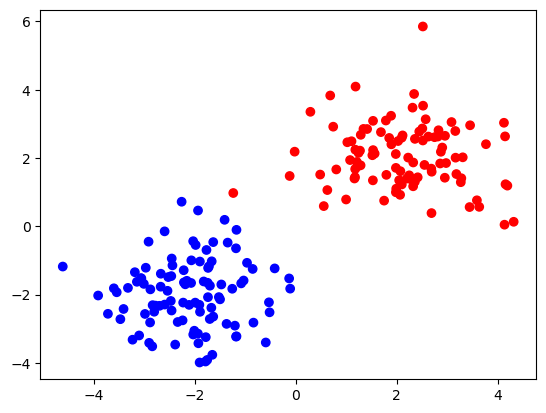

In [240]:
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap="bwr")
plt.show()

### 4.3 Initialize weights

In [241]:
# Initialize paramters
w = np.random.randn(X.shape[1],1)
b = 0.0

In [242]:
print("X shape:", X.shape)
print("w shape:", w.shape)

X shape: (200, 2)
w shape: (2, 1)


### 4.4 Training

In [243]:
def train():
    w = np.random.randn(X.shape[1],1)
    b = 0.0
    epochs = 100
    lr = 0.01

    losses = []

    for i in range(epochs):
        y_hat = predict_proba(X,w,b)
        loss = loss_fn(y,y_hat)
        losses.append(loss)
        dw,db = gradients(X,y,y_hat)

        w -= lr* dw
        b -= lr *db
        
    return w, b, losses


In [244]:
w,b,losses = train()


In [245]:
def loss_curve(losses):
    plt.plot(losses)
    plt.xlabel("epochs")
    plt.ylabel("Loss")
    plt.show()

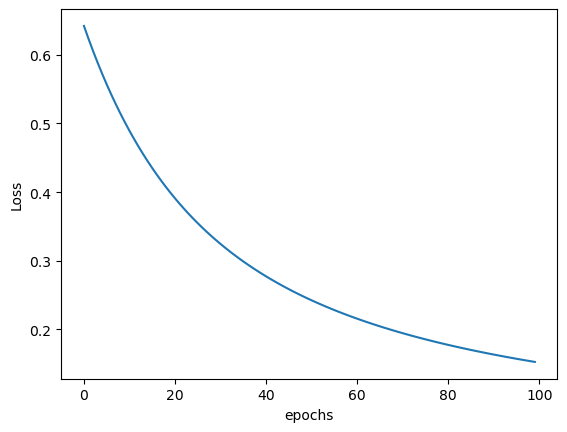

In [246]:
loss_curve(losses)

In [247]:
def visualize():
    plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap="bwr")

    # Short decision boundary
    x_min, x_max = X[:,0].min(), X[:,0].max()
    x_vals = np.linspace(x_min, x_max, 50)
    y_vals = -(w[0,0]/w[1,0])*x_vals - b/w[1,0]

    plt.plot(x_vals, y_vals, color='black', linewidth=2, label="Decision boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("2D Logistic Regression")
    plt.legend()
    plt.show()

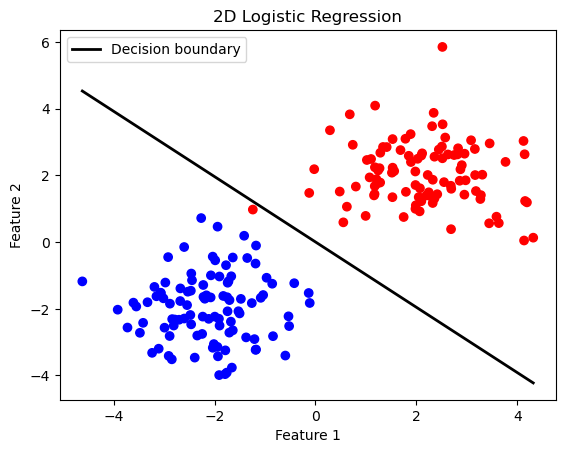

In [248]:
visualize()

## 5 . Failure cases
### 5.1 Non-linear (circular data)

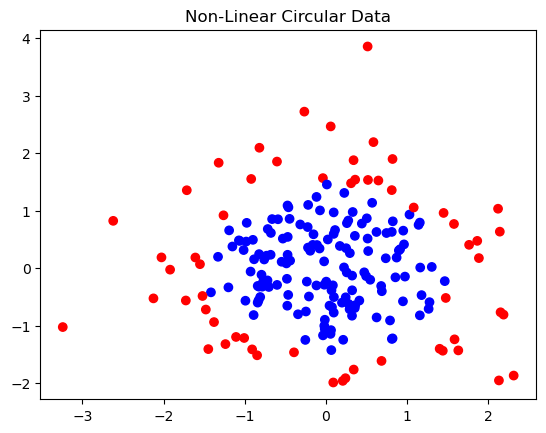

In [249]:
def make_circular_data(n=200):
    np.random.seed(42)
    
    X = np.random.randn(n,2)
    
    radius = np.sqrt(X[:,0]**2 + X[:,1]**2)
    
    y = (radius > 1.5).astype(int).reshape(-1,1)
    
    return X, y


X, y = make_circular_data()

plt.scatter(X[:,0], X[:,1], c=y.ravel(),cmap="bwr")
plt.title("Non-Linear Circular Data")
plt.show()

In [250]:
w,b,losses = train()

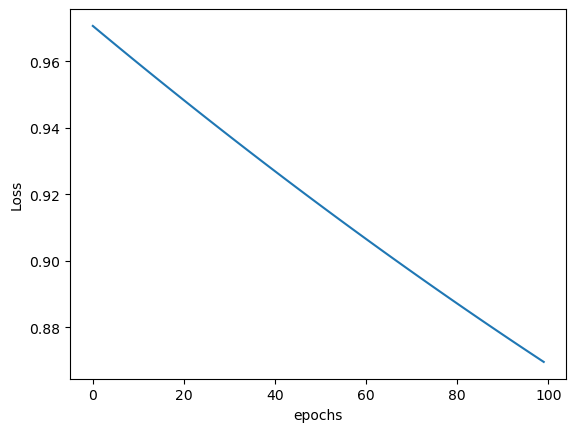

In [251]:
loss_curve(losses)

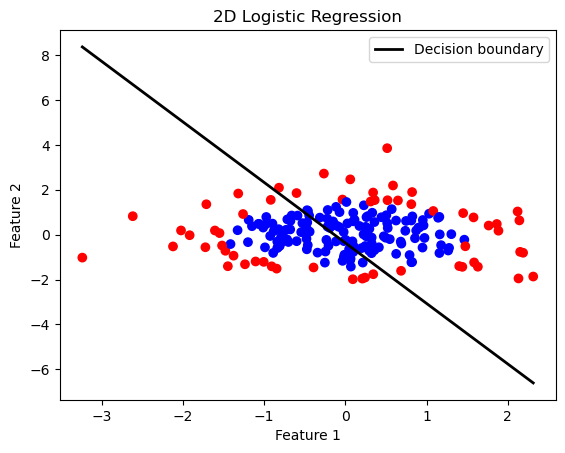

In [252]:
visualize()

### 5.2 Nearly perfect seperation

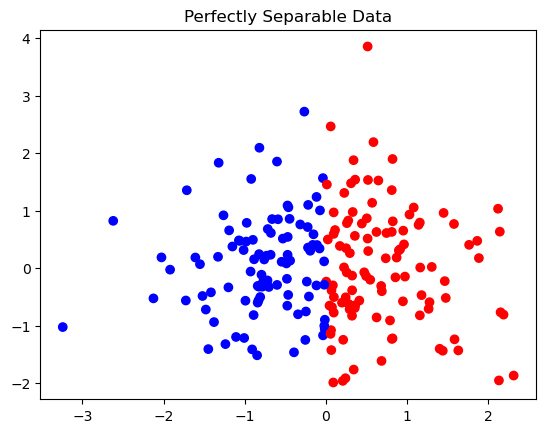

In [253]:
def make_perfect_separation(n=200):
    np.random.seed(42)
    
    X = np.random.randn(n,2)
    y = (X[:,0] > 0).astype(int).reshape(-1,1)
    
    return X, y


X, y = make_perfect_separation()

plt.scatter(X[:,0], X[:,1], c=y.ravel(),cmap="bwr")
plt.title("Perfectly Separable Data")
plt.show()

In [254]:
w,b,losses = train()

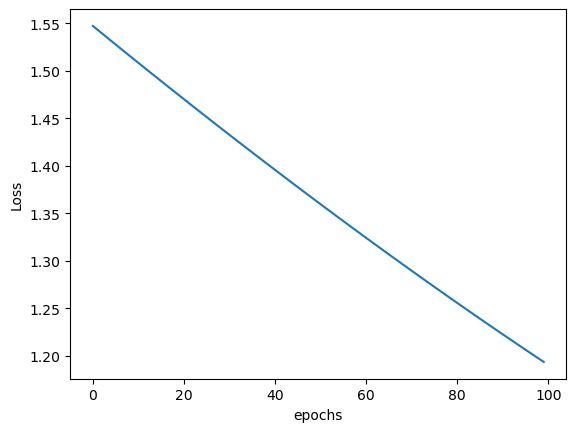

In [255]:
loss_curve(losses)

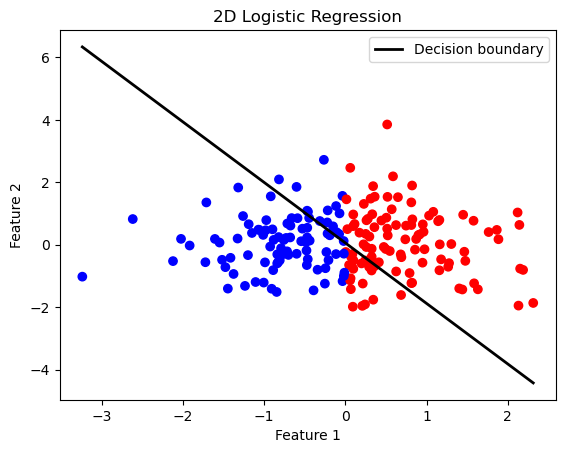

In [256]:
visualize()

it can’t perfectly separate overlapping or near-separable data, so it tries to compromise, which can slow convergence and flatten the loss curve.